In [ ]:
# 1. Подберите парамтеры алгоритма разрастания регионов так, чтобы был выделен весь участок газона.
# 2. Реализуйте вычисление критерия однородности, отличного от представленного. Сравните результаты.
# 3. Применить алгоритм сегментации watershed+distance transform для задачи подсчета пальмовых деревьев.

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import math

# 1. Подберите парамтеры алгоритма разрастания регионов так, чтобы был выделен весь участок газона.

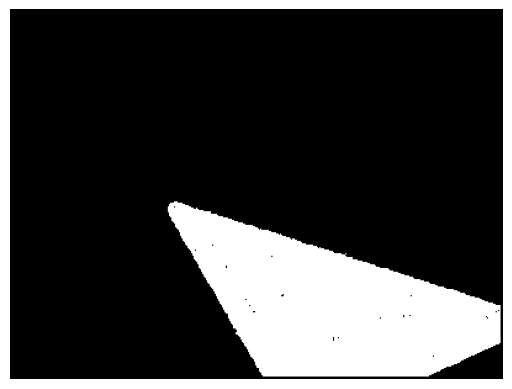

In [8]:
image_gray = cv2.imread('sar_1.jpg', cv2.IMREAD_GRAYSCALE)
def homo_average(img, mask, point, T):
    av_val = img[mask > 0].sum() / np.count_nonzero(img[mask > 0])
                                                            
    if abs(av_val - img[point]) <= T:
        return True
    
    return False

def region_growing(image, seed_point, homo_fun, r, T):
    mask = np.zeros(image_gray.shape, np.uint8)
    mask[seed_point] = 1
    count = 1
    while count > 0:
        count = 0
        local_mask = np.zeros(image_gray.shape, np.uint8)
        for i in range(r,image.shape[0] - r):
            for j in range(r,image.shape[1] - r):
                if mask[i,j]==0 and mask[i - r:i + r, j-r: j+r].sum() > 0:
                    if homo_fun(image, mask, (i,j), T):
                        local_mask[i,j] = 1
        count = np.count_nonzero(local_mask)
        mask += local_mask
        
    return mask*255

seed_point = (250,250)
mask = region_growing(image_gray, seed_point, homo_average, 2, 30)

plt.imshow(mask, cmap="gray")
plt.axis("off")
plt.show()

# 2. Реализуйте вычисление критерия однородности, отличного от представленного. Сравните результаты.

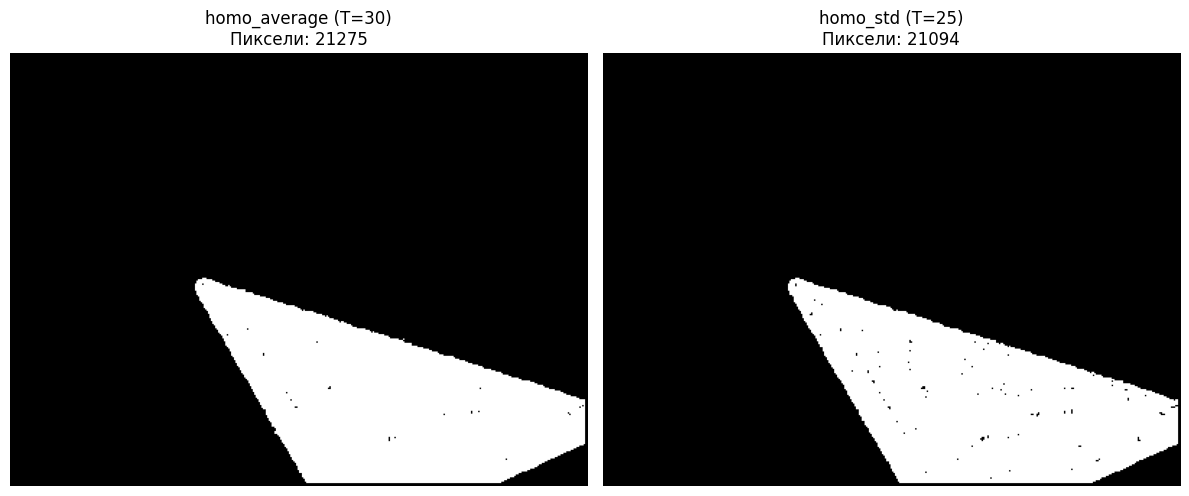

In [10]:
def homo_std(img, mask, point, T):
    """
    Критерий однородности на основе стандартного отклонения.
    Чем выше T, тем больше вариаций допускается.
    """
    region_pixels = img[mask > 0]
    if len(region_pixels) == 0:
        return False
    
    # Вычислить stddev региона
    std_val = np.std(region_pixels)
    
    # Проверить, не превышает ли stddev текущего пикселя допуск
    return abs(img[point] - region_pixels.mean()) <= T

seed_point = (250, 250)

mask_avg = region_growing(image_gray, seed_point, homo_average, 2, 30)

mask_std = region_growing(image_gray, seed_point, homo_std, 2, 25)

plt.figure(figsize=(12, 10))
plt.subplot(1, 2, 1)
plt.imshow(mask_avg, cmap='gray')
plt.title(f'homo_average (T=30)\nПиксели: {np.count_nonzero(mask_avg)}')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(mask_std, cmap='gray')
plt.title(f'homo_std (T=25)\nПиксели: {np.count_nonzero(mask_std)}')
plt.axis('off')



plt.tight_layout()
plt.show()

# 3. Применить алгоритм сегментации watershed+distance transform для задачи подсчета пальмовых деревьев.

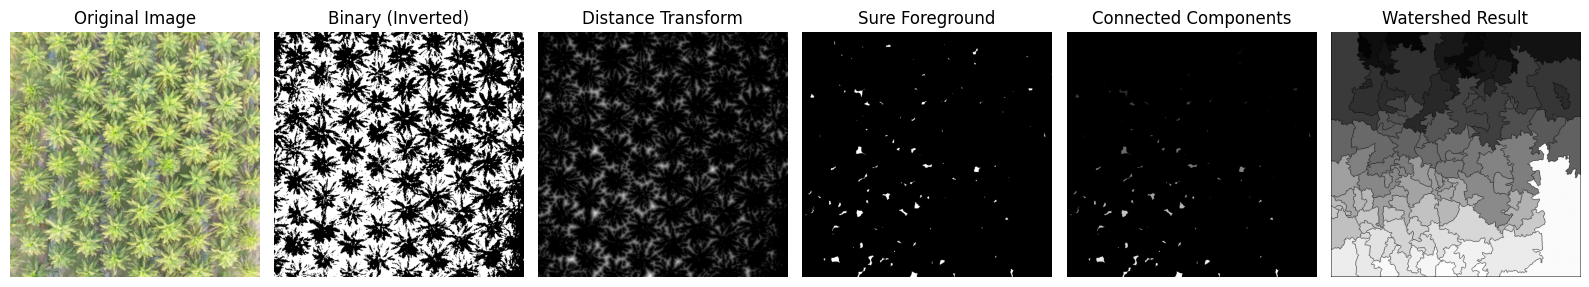

Palm count: 112


In [44]:
import copy

image_palm = cv2.imread("palm_1.jpg")
image_palm_gray = cv2.cvtColor(image_palm, cv2.COLOR_BGR2GRAY)
ret, thresh = cv2.threshold(image_palm_gray,0,255, cv2.THRESH_BINARY_INV+cv2.THRESH_OTSU)

dist = cv2.distanceTransform(thresh, cv2.DIST_L2, 5)

ret, sure_fg = cv2.threshold(dist, 0.486 * dist.max(), 255, cv2.THRESH_BINARY)

sure_fg = sure_fg.astype(np.uint8)
ret, markers = cv2.connectedComponents(sure_fg)

markers_watershed = copy.deepcopy(markers)
markers_watershed = cv2.watershed(image_palm, markers_watershed)

plt.figure(figsize=(16, 3))

plt.subplot(1, 6, 1)
plt.imshow(cv2.cvtColor(image_palm, cv2.COLOR_BGR2RGB))
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 6, 2)
plt.imshow(thresh, cmap='gray')
plt.title('Binary (Inverted)')
plt.axis('off')

plt.subplot(1, 6, 3)
plt.imshow(dist, cmap='gray')
plt.title('Distance Transform')
plt.axis('off')

plt.subplot(1, 6, 4)
plt.imshow(sure_fg, cmap='gray')
plt.title('Sure Foreground')
plt.axis('off')

plt.subplot(1, 6, 5)
plt.imshow(markers, cmap='gray')
plt.title('Connected Components')
plt.axis('off')

plt.subplot(1, 6, 6)
plt.imshow(markers_watershed, cmap='gray')
plt.title('Watershed Result')
plt.axis('off')

plt.tight_layout()
plt.show()

palm_count = len(np.unique(markers)) - 1
print(f'Palm count: {palm_count}')